# Brain Stroke Prediction - Classification

## Section 1: Introduction and Dataset Overview

### Problem Statement

Stroke is a major cause of death and long-term disability worldwide. Early identification of high-risk individuals can enable timely intervention and improve patient outcomes.

This project develops a binary classification model to *predict* whether a patient is likely to suffer a stroke *(Class 1)* or not *(Class 0)* using demographic and clinical features.

The primary evaluation metric is **Recall for Class 1**, as correctly identifying stroke cases is more important than *avoiding false positives*. In a medical setting, missing a true stroke case (false negative) can have *serious consequences*.


### Dataset Description

The training dataset (`brain_stroke_data.csv`) contains 4,482 patient records with 11 columns. The unseen dataset (`brain_stroke_unseen.csv`) contains 499 records with 10 columns (the `stroke` target column is absent, as expected for held-out evaluation).

| Column | Type | Description |
|---|---|---|
| `gender` | Categorical | Patient sex: Male or Female |
| `age` | Numeric | Patient age in years |
| `hypertension` | Binary (0/1) | Whether the patient has hypertension |
| `heart_disease` | Binary (0/1) | Whether the patient has heart disease |
| `ever_married` | Categorical | Marital status: Yes or No |
| `work_type` | Categorical | Employment category: Private, Self-employed, Govt_job, children |
| `Residence_type` | Categorical | Urban or Rural residence |
| `avg_glucose_level` | Numeric | Average blood glucose level (mg/dL) |
| `bmi` | Numeric | Body Mass Index |
| `smoking_status` | Categorical | Smoking history: never smoked, formerly smoked, smokes, Unknown |
| `stroke` | Binary (0/1) | **Target variable** -> 1 = stroke occurred, 0 = no stroke |

The `smoking_status` value **"Unknown"** indicates that the patient's smoking history *was not recorded*; it is a legitimate data category and is **not treated as a missing value**. Similarly, `work_type = "children"` is a valid category representing minors and is retained as-is.

In [34]:
# Import all required libraries

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

from imblearn.over_sampling import SMOTE

# Consistent plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [10]:
# Load the training and unseen datasets using relative paths

df = pd.read_csv('brain_stroke_data.csv')
df_unseen = pd.read_csv('brain_stroke_unseen.csv')

print(f"Training dataset shape: {df.shape}")
print(f"Unseen dataset shape: {df_unseen.shape}")

Training dataset shape: (4482, 11)
Unseen dataset shape: (499, 10)


In [11]:
# training data inspection (few rows)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Female,46.0,0,0,Yes,Private,Urban,78.79,42.4,smokes,0
1,Female,65.0,0,0,Yes,Self-employed,Urban,248.24,27.0,smokes,0
2,Male,70.0,1,0,Yes,Self-employed,Rural,118.81,26.0,smokes,0
3,Male,47.0,0,0,Yes,Private,Urban,111.84,33.7,Unknown,0
4,Male,31.0,0,0,Yes,Govt_job,Urban,65.70,30.4,formerly smoked,0


In [12]:
# unseen data inspection (few rows)
df_unseen.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,Female,49.0,0,0,Yes,Private,Rural,56.11,28.7,smokes
1,Male,75.0,0,0,Yes,Private,Rural,75.47,24.5,formerly smoked
2,Female,71.0,0,0,Yes,Private,Rural,100.61,19.2,Unknown
3,Female,12.0,0,0,No,children,Rural,85.97,35.7,Unknown
4,Male,63.0,0,0,Yes,Private,Rural,104.79,24.1,Unknown


In [13]:
# column data types
df.dtypes

gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [14]:
# statistics summary
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4482.000000,4482.000000,4482.000000,4482.000000,4482.000000,4482.000000
mean,43.446693,0.098394,0.054663,105.761430,28.466064,0.049755
std,22.592327,0.297879,0.227347,44.943627,6.764658,0.217462
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,26.000000,0.000000,0.000000,77.192500,23.600000,0.000000
50%,45.000000,0.000000,0.000000,91.680000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.637500,32.575000,0.000000
max,82.000000,1.000000,1.000000,267.760000,48.900000,1.000000


## Section 2: Exploratory Data Analysis (EDA)

The EDA phase is used to assess data quality and explore relationships between features and stroke occurrence. Key findings and any resulting preprocessing decisions are anottated alongside each visualisation.


In [16]:
# check for missing values (both datasets)

print("Missing values - training data:")
print(df.isnull().sum())
print()
print("Missing values - unseen data:")
print(df_unseen.isnull().sum())

Missing values - training data:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Missing values - unseen data:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
dtype: int64


**Finding:** There are *no* missing values in either dataset. The `smoking_status = "Unknown"` entries are not missing values - they represent patients whose smoking history was not recorded, and are kept as a valid category.

In [17]:
# check for duplicate rows
print(f"duplicate rows in training data: {df.duplicated().sum()}")
print(f"duplicate rows in unseen data: {df_unseen.duplicated().sum()}")

duplicate rows in training data: 0
duplicate rows in unseen data: 0


**Finding:** No duplicate rows were found.

In [18]:
# unique values per column

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values  ->  {df[col].unique()[:8]}")

gender: 2 unique values  ->  ['Female' 'Male']
age: 104 unique values  ->  [46. 65. 70. 47. 31. 53. 52.  5.]
hypertension: 2 unique values  ->  [0 1]
heart_disease: 2 unique values  ->  [0 1]
ever_married: 2 unique values  ->  ['Yes' 'No']
work_type: 4 unique values  ->  ['Private' 'Self-employed' 'Govt_job' 'children']
Residence_type: 2 unique values  ->  ['Urban' 'Rural']
avg_glucose_level: 3580 unique values  ->  [ 78.79 248.24 118.81 111.84  65.7  113.21  67.5   80.81]
bmi: 338 unique values  ->  [42.4 27.  26.  33.7 30.4 28.6 27.7 39. ]
smoking_status: 4 unique values  ->  ['smokes' 'Unknown' 'formerly smoked' 'never smoked']
stroke: 2 unique values  ->  [0 1]


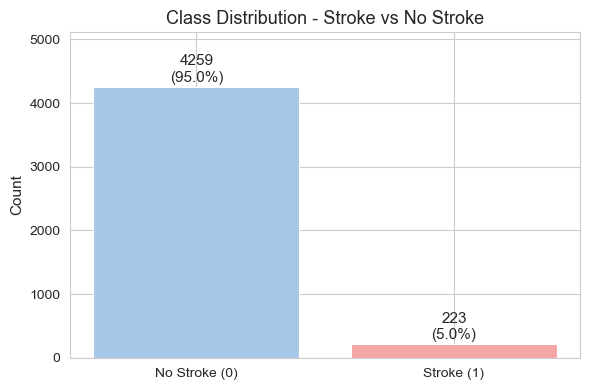

In [20]:
# class distribution - imbalance visualisation check
fig, ax = plt.subplots(figsize=(6, 4))

counts = df['stroke'].value_counts()

bars = ax.bar(
    ['No Stroke (0)', 'Stroke (1)'],
    counts.values,
    color=['#A7C7E7', '#F4A6A6'],  # pastel blue, pastel red
    edgecolor='white',
    linewidth=0.8
)

for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{count}\n({count/len(df)*100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.set_title('Class Distribution - Stroke vs No Stroke')
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.2)

plt.tight_layout()
plt.show()

**Class Imbalance:** The dataset is highly imbalanced, with approximately **95%** of patients in the *no-stroke* class and only **5%** in the *stroke* class. Therefore, a model could achieve high accuracy by predicting no stroke for every patient while missing all stroke cases. To address this, accuracy is not used as the main evaluation metric, and SMOTE oversampling is applied during training (see Section 4).


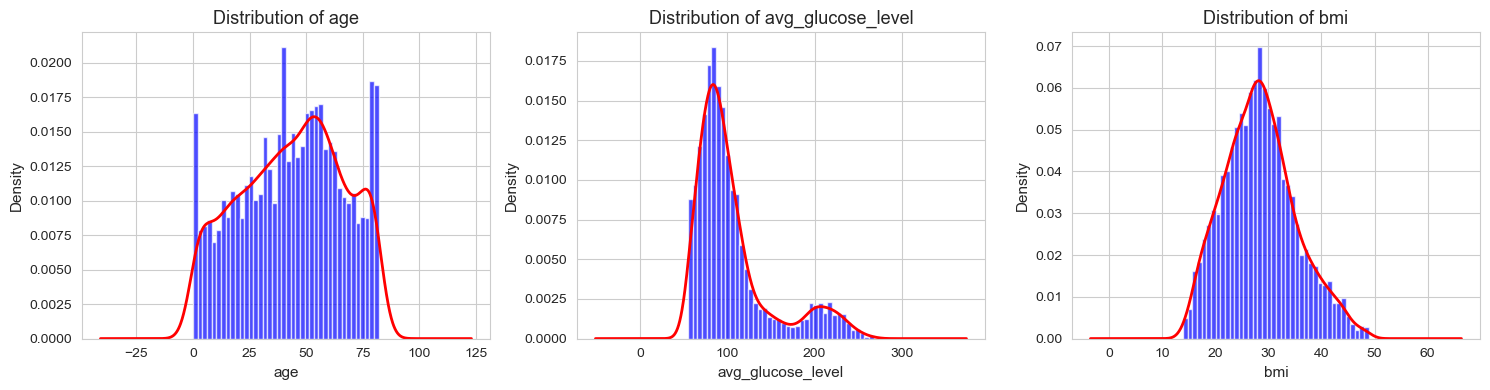

Skewness of age: -0.144
Skewness of avg_glucose_level: 1.594
Skewness of bmi: 0.371


In [25]:
# Histograms and KDE plots for numeric features
numeric_features = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, numeric_features):
    ax.hist(df[col], bins=40, color='blue', edgecolor='white',
            alpha=0.7, density=True)
    df[col].plot(kind='kde', ax=ax, color='red', linewidth=2)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.tight_layout()
plt.show()

# Print skewness for each feature
for col in numeric_features:
    print(f"Skewness of {col}: {df[col].skew():.3f}")

### Numeric Feature Distributions

- **Age** is spread across a wide range of values, from young children to older adults, with a slightly higher concentration of older patients.
- **Average Glucose Level** is right-skewed, with most patients having values below 120 mg/dL and a smaller group showing much higher glucose levels. These higher values may be associated with conditions such as diabetes.
- **BMI** is also slightly right-skewed, with most patients falling within the overweight range and fewer patients having very high BMI values.

Both **average glucose level** and **BMI** show some imbalance, which is common in healthcare datasets. To ensure all numeric features are on a comparable scale, **StandardScaler** will be applied during preprocessing, particularly for models such as Logistic Regression.

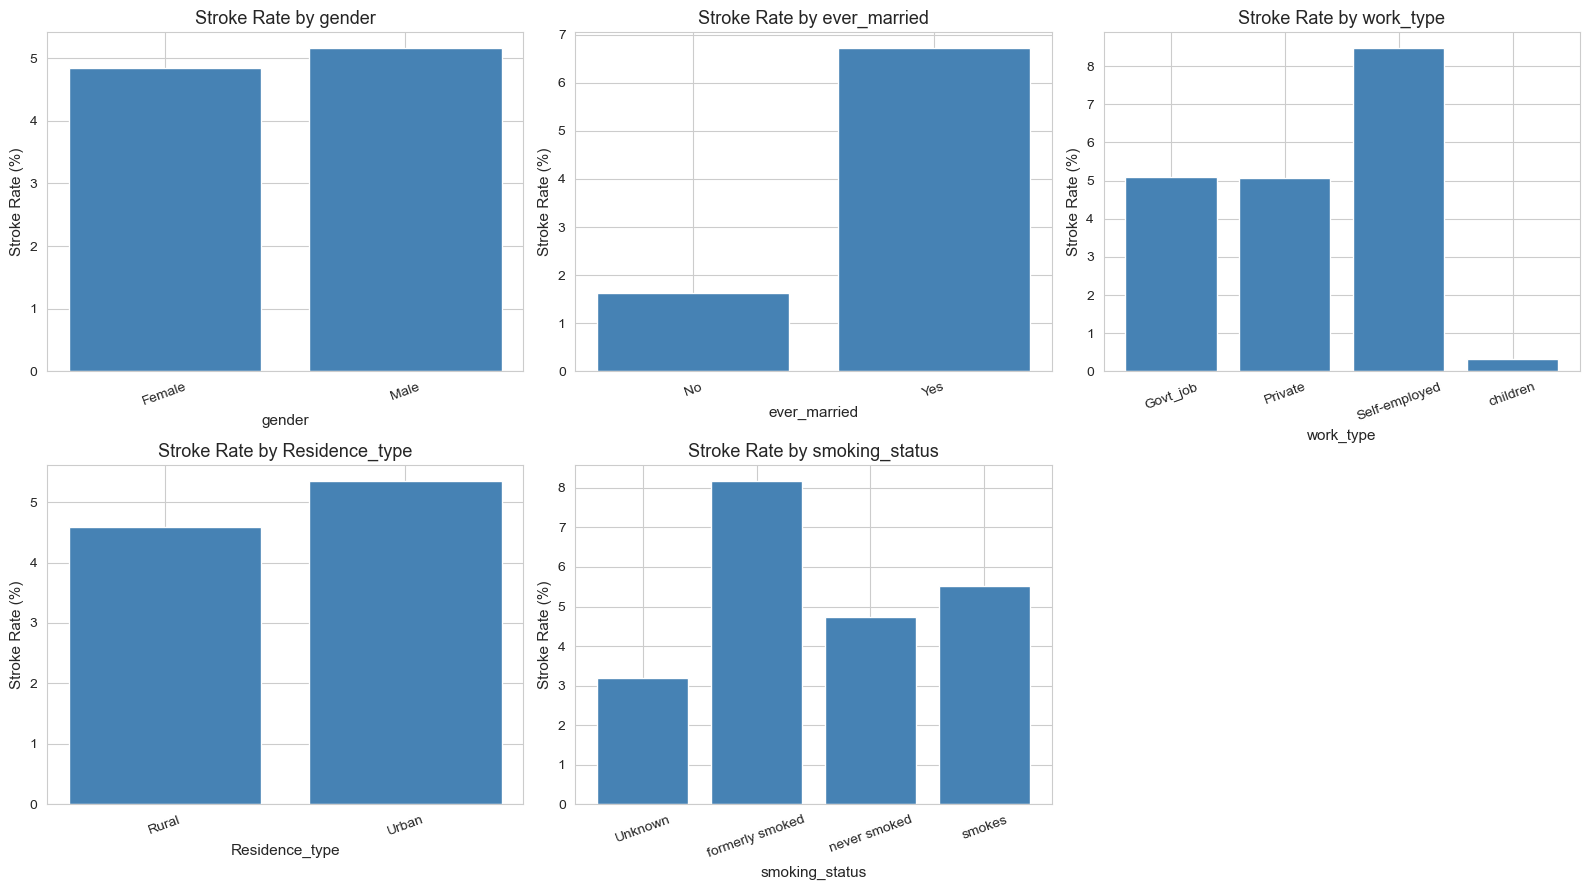

In [29]:
# stroke rate by each categorical feature
categorical_features = ['gender', 'ever_married', 'work_type','Residence_type', 'smoking_status']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    stroke_rate = df.groupby(col)['stroke'].mean().reset_index()
    stroke_rate.columns = [col, 'stroke_rate']
    axes[i].bar(stroke_rate[col], stroke_rate['stroke_rate'] * 100,
                color='steelblue', edgecolor='white')
    axes[i].set_title(f'Stroke Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Stroke Rate (%)')
    axes[i].tick_params(axis='x', rotation=20)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

### Categorical Feature Analysis

- **Gender:** Stroke rates are fairly similar across males and females, suggesting that gender on its own may not be a strong predictor of stroke risk.
- **Ever Married:** Patients who have been married appear more likely to have experienced a stroke. This is likely related to age, as older individuals are both more likely to have been married and more likely to suffer a stroke.
- **Work Type:** Stroke rates tend to be higher among self-employed individuals and those working in government roles. As expected, patients in the *children* category have very few stroke cases.
- **Residence Type:** Urban and rural patients show very similar stroke rates, indicating that place of residence may have limited predictive value.
- **Smoking Status:** Former and current smokers show slightly higher stroke rates than never-smokers. The **Unknown** category also displays a meaningful stroke rate, so it will be retained as a separate category rather than being imputed.

Overall, **ever_married**, **work_type**, and **smoking_status** appear to show some relationship with stroke occurrence and may provide useful information to the predictive models.

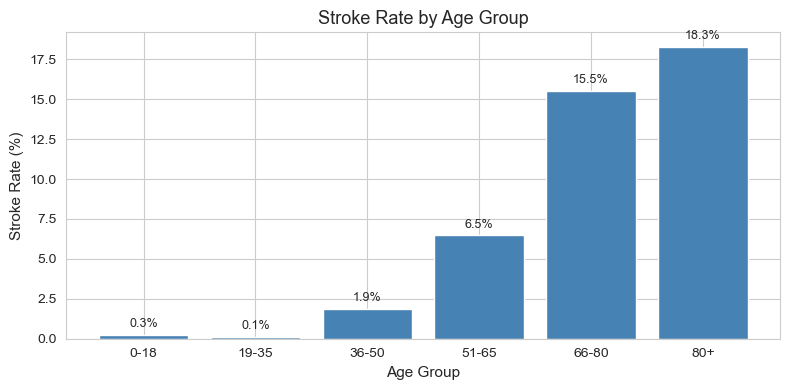

In [30]:
# stroke rate by age group
bins = [0, 18, 35, 50, 65, 80, 100]
labels = ['0-18', '19-35', '36-50', '51-65', '66-80', '80+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

stroke_by_age = df.groupby('age_group', observed=True)['stroke'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(stroke_by_age.index, stroke_by_age.values,
       color='steelblue', edgecolor='white')
ax.set_title('Stroke Rate by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Stroke Rate (%)')
for i, v in enumerate(stroke_by_age.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# Drop the temporary column
df.drop(columns=['age_group'], inplace=True)

### Age Group Analysis

Stroke rates increase noticeably with age. Patients aged 51–65 show a higher incidence of stroke than younger age groups, with rates rising further among those aged 66–80 and 80+. In contrast, stroke cases are very rare among patients under 35.

This pattern suggests that **age is one of the strongest predictors of stroke risk** in the dataset. For modelling purposes, age will be retained as a continuous numeric feature and scaled during preprocessing.

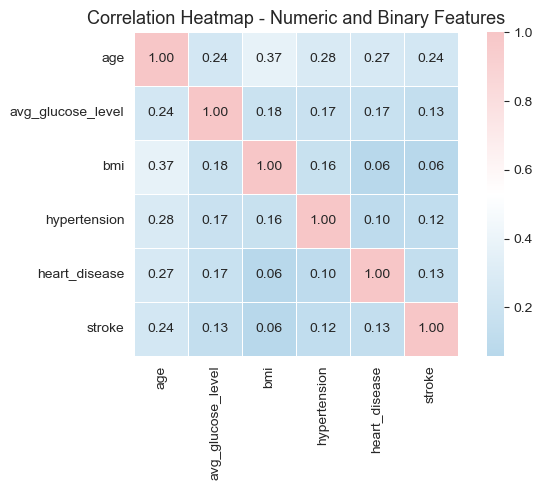

In [35]:
# Create correlation matrix
corr_cols = ['age', 'avg_glucose_level', 'bmi',
             'hypertension', 'heart_disease', 'stroke']

corr_matrix = df[corr_cols].corr()

# Custom pastel colour map
pastel_cmap = LinearSegmentedColormap.from_list(
    'pastel_corr',
    ['#B8D8EB', '#FFFFFF', '#F7C6C7']
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap=pastel_cmap,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Correlation Heatmap - Numeric and Binary Features')
plt.tight_layout()
plt.show()

### Correlation Analysis

Age has the strongest relationship with stroke among the numeric features, followed by hypertension and heart disease. Average glucose level and BMI also show positive relationships with stroke, although these are weaker.

There are no strong correlations between the predictor variables themselves, suggesting that *multicollinearity* is not a concern and all features can be retained for modelling.

Overall, the relatively low correlation values are not surprising, as stroke is influenced by multiple factors rather than any single characteristic.

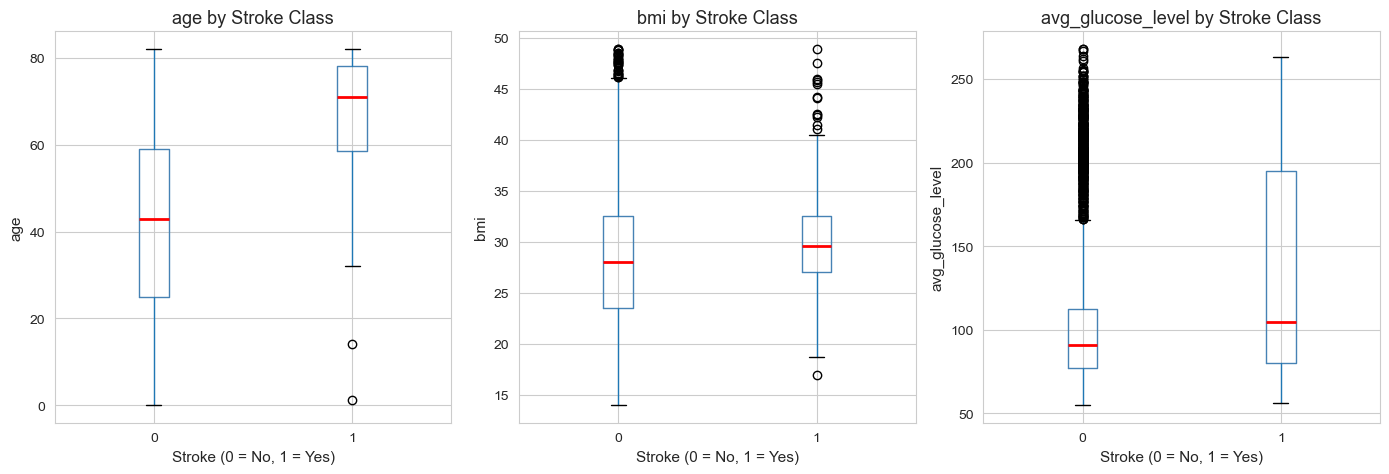

In [37]:
# boxplots of numeric features vs stroke class
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
features = ['age', 'bmi', 'avg_glucose_level']

for ax, feat in zip(axes, features):
    df.boxplot(column=feat, by='stroke', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'{feat} by Stroke Class')
    ax.set_xlabel('Stroke (0 = No, 1 = Yes)')
    ax.set_ylabel(feat)

plt.suptitle('')
plt.tight_layout()
plt.show()

### Boxplot Analysis

- **Age:** Patients who experienced a stroke tend to be noticeably older than those who did not. The difference in age distributions is clear, suggesting that age is one of the strongest predictors of stroke in the dataset.
- **BMI:** There is considerable overlap between the two groups, although stroke patients generally have slightly higher BMI values. This suggests that BMI may contribute to stroke risk but is unlikely to be a strong predictor on its own.
- **Average Glucose Level:** Patients who experienced a stroke tend to have higher glucose levels and greater variation in their readings. This supports the idea that elevated glucose levels may be associated with an increased risk of stroke.

Overall, **age appears to provide the clearest separation between stroke and non-stroke patients**, while BMI and average glucose level show weaker but still potentially useful relationships.

## Section 3: Data Preprocessing

### Encoding Strategy

Different types of features require different preprocessing approaches.

- **Binary categorical features** (`gender`, `ever_married`, `Residence_type`) contain only two categories, so they are encoded as 0 and 1 using an Ordinal Encoder. Keeping the dataset compact without losing any information.

- **Multi-class categorical features** (`work_type`, `smoking_status`) contain several distinct categories with no natural order. These features are transformed using *One-Hot Encoding*, creating a separate binary column for each category. This avoids introducing artificial relationships between categories.

- **Numeric features** (`age`, `avg_glucose_level`, `bmi`) are standardised using StandardScaler. This places all numeric variables on a similar scale, which is particularly important for Logistic Regression and can also help improve model training efficiency.

### Pipeline Design

A `ColumnTransformer` is used to apply all preprocessing steps in a single pipeline. This ensures that the same transformations are applied consistently across the training, test, and unseen datasets. It also helps to prevent data leakage by calculating scaling and encoding parameters using only the training data.

In [40]:
# separate features and target variable
X = df.drop(columns=['stroke'])
y = df['stroke']

# define feature groups by encoding strategy
binary_cats = ['gender', 'ever_married', 'Residence_type']
multi_cats = ['work_type', 'smoking_status']
numeric = ['age', 'avg_glucose_level', 'bmi']

print("Binary categoricals (OrdinalEncoder):", binary_cats)
print("Multi-class categoricals (OneHotEncoder):", multi_cats)
print("Numeric features (StandardScaler):", numeric)
print("Binary pass-through (already encoded): ['hypertension', 'heart_disease']")

Binary categoricals (OrdinalEncoder): ['gender', 'ever_married', 'Residence_type']
Multi-class categoricals (OneHotEncoder): ['work_type', 'smoking_status']
Numeric features (StandardScaler): ['age', 'avg_glucose_level', 'bmi']
Binary pass-through (already encoded): ['hypertension', 'heart_disease']


In [41]:
# build the ColumnTransformer preprocessing pipeline
# OrdinalEncoder for binary categoricals, OneHotEncoder for multi-class,
# StandardScaler for numeric; hypertension and heart_disease pass through unchanged
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric),
    ('bin_cat', OrdinalEncoder(), binary_cats),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False), multi_cats),
], remainder='passthrough')

print("preprocessor built successfully!!!")
print(preprocessor)

preprocessor built successfully!!!
ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['age', 'avg_glucose_level', 'bmi']),
                                ('bin_cat', OrdinalEncoder(),
                                 ['gender', 'ever_married', 'Residence_type']),
                                ('ohe',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['work_type', 'smoking_status'])])


### Notes on Preprocessing Decisions

- The **"Unknown"** category in `smoking_status` is retained rather than imputed.
- The **"children"** category in `work_type` is kept as a valid category, as it represents genuine observations within the dataset and may help capture age-related patterns.
- The `hypertension` and `heart_disease` features are already stored as binary values (0/1), so no additional preprocessing is required.